In [ ]:
import pandas as pd
df=pd.read_csv("/content/archive (2).zip")
df

,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,(2018– ),TV-14,30 min,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...","177,031"
1,The Crown,(2016– ),TV-MA,58 min,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...","199,885"
2,Better Call Saul,(2015–2022),TV-MA,46 min,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...","501,384"
3,Devil in Ohio,(2022),TV-MA,356 min,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...","9,773"
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24 min,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...","15,413"
...,...,...,...,...,...,...,...,...,...
9952,The Imperfects,(2022– ),TV-MA,45 min,"Action, Adventure, Drama",6.3,After an experimental gene therapy turns them ...,"['Morgan Taylor Campbell, ', 'Italia Ricci, ',...","3,130"
9953,The Walking Dead,(2010–2022),TV-MA,44 min,"Drama, Horror, Thriller",8.1,Sheriff Deputy Rick Grimes wakes up from a com...,"['Andrew Lincoln, ', 'Norman Reedus, ', 'Melis...","970,067"
9954,The Crown,(2016– ),TV-MA,58 min,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...","199,898"
9955,Supernatural,(2005–2020),TV-14,44 min,"Drama, Fantasy, Horror",8.4,Two brothers follow their father's footsteps a...,"['Jared Padalecki, ', 'Jensen Ackles, ', 'Jim ...","439,601"


# Task
Realiza un Análisis Exploratorio de Datos (EDA) en español sobre el conjunto de datos "IMDb Movies India.csv".

## Comprensión de los datos

### Subtask:
Inspeccionar las primeras filas del DataFrame y la información general del conjunto de datos para entender su estructura y contenido.


**Reasoning**:
Display the first 5 rows and the information of the dataframe to understand its structure and content as requested by the instructions.



In [ ]:
display(df.head())
df.info()

,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,(2018– ),TV-14,30 min,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...","177,031"
1,The Crown,(2016– ),TV-MA,58 min,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...","199,885"
2,Better Call Saul,(2015–2022),TV-MA,46 min,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...","501,384"
3,Devil in Ohio,(2022),TV-MA,356 min,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...","9,773"
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24 min,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...","15,413"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9957 entries, 0 to 9956
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        9957 non-null   object 
 1   year         9430 non-null   object 
 2   certificate  6504 non-null   object 
 3   duration     7921 non-null   object 
 4   genre        9884 non-null   object 
 5   rating       8784 non-null   float64
 6   description  9957 non-null   object 
 7   stars        9957 non-null   object 
 8   votes        8784 non-null   object 
dtypes: float64(1), object(8)
memory usage: 700.2+ KB


## Estadísticas descriptivas

### Subtask:
Calcular estadísticas descriptivas para las columnas numéricas y categóricas para identificar tendencias, valores atípicos y la distribución de los datos.


**Reasoning**:
Calcular y mostrar las estadísticas descriptivas para las columnas numéricas y categóricas del DataFrame.



In [ ]:
numeric_stats = df.describe()
categorical_stats = df.describe(include='object')

print("Estadísticas Descriptivas para Columnas Numéricas:")
display(numeric_stats)

print("\nEstadísticas Descriptivas para Columnas Categóricas:")
display(categorical_stats)

Estadísticas Descriptivas para Columnas Numéricas:


,rating
count,8784.000000
mean,6.764515
std,1.214840
min,1.700000
25%,6.100000
50%,6.900000
75%,7.600000
max,9.900000



Estadísticas Descriptivas para Columnas Categóricas:


,title,year,certificate,duration,genre,description,stars,votes
count,9957,9430,6504,7921,9884,9957,9957,8784
unique,7912,498,20,291,569,9433,8615,4862
top,Top Gear,(2020),TV-MA,60 min,Comedy,Add a Plot,[],30
freq,92,663,2520,385,859,434,403,33


## Manejo de valores faltantes

### Subtask:
Identificar y abordar los valores faltantes en el conjunto de datos.


**Reasoning**:
Identify the columns with missing values and the count of missing values per column.



In [ ]:
missing_values = df.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values)

Valores faltantes por columna:
title             0
year            527
certificate    3453
duration       2036
genre            73
rating         1173
description       0
stars             0
votes          1173
dtype: int64


**Reasoning**:
Address the missing values based on the nature and quantity of missing data in each column. For 'certificate', 'duration', 'rating', and 'votes' which have a significant number of missing values, dropping them is not ideal. For 'year' and 'genre' which have fewer missing values, imputation with mode is a reasonable strategy as they are categorical or can be treated as such for filling missing values. The 'certificate', 'duration', 'rating', and 'votes' columns will be kept for now, and we will decide on a strategy later if needed based on the analysis goals.



In [ ]:
df['year'] = df['year'].fillna(df['year'].mode()[0])
df['genre'] = df['genre'].fillna(df['genre'].mode()[0])
print("\nValores faltantes después de la imputación:")
print(df.isnull().sum())


Valores faltantes después de la imputación:
title             0
year              0
certificate    3453
duration       2036
genre             0
rating         1173
description       0
stars             0
votes          1173
dtype: int64


## Análisis de la columna de duración

### Subtask:
Limpiar y convertir la columna 'duration' a un formato numérico para facilitar el análisis.


**Reasoning**:
Clean and convert the 'duration' column to a numerical format by removing ' min' and converting to integer type, then display the first few rows and the data type.



In [ ]:
df['duration'] = df['duration'].str.replace(' min', '', regex=False)
df['duration'] = pd.to_numeric(df['duration'])
display(df.head())
print(df['duration'].dtype)

,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,(2018– ),TV-14,30.0,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...","177,031"
1,The Crown,(2016– ),TV-MA,58.0,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...","199,885"
2,Better Call Saul,(2015–2022),TV-MA,46.0,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...","501,384"
3,Devil in Ohio,(2022),TV-MA,356.0,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...","9,773"
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24.0,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...","15,413"


float64


## Análisis de la columna de votos

### Subtask:
Limpiar y convertir la columna 'votes' a un formato numérico para facilitar el análisis.


**Reasoning**:
Clean and convert the 'votes' column to a numerical format by removing commas and converting the data type, then display the head and the data type to verify the changes.



In [ ]:
df['votes'] = df['votes'].str.replace(',', '', regex=False)
df['votes'] = pd.to_numeric(df['votes'])
display(df.head())
print(df['votes'].dtype)

,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,(2018– ),TV-14,30.0,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...",177031.0
1,The Crown,(2016– ),TV-MA,58.0,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...",199885.0
2,Better Call Saul,(2015–2022),TV-MA,46.0,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...",501384.0
3,Devil in Ohio,(2022),TV-MA,356.0,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...",9773.0
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24.0,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...",15413.0


float64


## Análisis de la columna de estrellas

### Subtask:
Limpiar la columna 'stars' para un análisis posterior.


**Reasoning**:
Clean the 'stars' column by removing brackets and single quotes.



In [ ]:
df['stars'] = df['stars'].str.replace('[', '', regex=False)
df['stars'] = df['stars'].str.replace(']', '', regex=False)
df['stars'] = df['stars'].str.replace("'", '', regex=False)
display(df.head())

,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,(2018– ),TV-14,30.0,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"Ralph Macchio, , William Zabka, , Courtney Hen...",177031.0
1,The Crown,(2016– ),TV-MA,58.0,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"Claire Foy, , Olivia Colman, , Imelda Staunton...",199885.0
2,Better Call Saul,(2015–2022),TV-MA,46.0,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"Bob Odenkirk, , Rhea Seehorn, , Jonathan Banks...",501384.0
3,Devil in Ohio,(2022),TV-MA,356.0,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"Emily Deschanel, , Sam Jaeger, , Gerardo Celas...",9773.0
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24.0,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"Zach Aguilar, , Kenichiro Ohashi, , Emi Lo, , ...",15413.0


## Análisis de la columna de año

### Subtask:
Limpiar la columna 'year' para un análisis posterior.


**Reasoning**:
Clean the 'year' column by removing parentheses and extracting the first year from a range, then convert it to an integer type, and finally display the head of the dataframe and the datatype of the column.



In [ ]:
df['year'] = df['year'].str.replace(r'[()]', '', regex=True)
df['year'] = df['year'].apply(lambda x: x.split('–')[0] if isinstance(x, str) else x)
df['year'] = pd.to_numeric(df['year'])
display(df.head())
print(df['year'].dtype)

ValueError: Unable to parse string "II 2022" at position 11

**Reasoning**:
The previous code failed to convert the 'year' column to numeric due to non-numeric values like "II 2022". I will modify the code to handle these errors by coercing invalid parsing into NaN before converting to integer, and then display the head and the dtype of the column.



In [ ]:
df['year'] = df['year'].str.replace(r'[()]', '', regex=True)
df['year'] = df['year'].apply(lambda x: x.split('–')[0] if isinstance(x, str) else x)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['year'] = df['year'].astype('Int64')
display(df.head())
print(df['year'].dtype)

,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,2018,TV-14,30.0,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"Ralph Macchio, , William Zabka, , Courtney Hen...",177031.0
1,The Crown,2016,TV-MA,58.0,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"Claire Foy, , Olivia Colman, , Imelda Staunton...",199885.0
2,Better Call Saul,2015,TV-MA,46.0,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"Bob Odenkirk, , Rhea Seehorn, , Jonathan Banks...",501384.0
3,Devil in Ohio,2022,TV-MA,356.0,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"Emily Deschanel, , Sam Jaeger, , Gerardo Celas...",9773.0
4,Cyberpunk: Edgerunners,2022,TV-MA,24.0,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"Zach Aguilar, , Kenichiro Ohashi, , Emi Lo, , ...",15413.0


Int64


## Análisis de la columna de certificado

### Subtask:
Analizar la distribución de la columna 'certificate'.


**Reasoning**:
Calculate and print the value counts for the 'certificate' column to understand its distribution.



In [ ]:
certificate_distribution = df['certificate'].value_counts()
print("Distribución de la columna 'certificate':")
print(certificate_distribution)

Distribución de la columna 'certificate':
certificate
TV-MA        2520
TV-14        1209
TV-PG         543
R             472
Not Rated     467
TV-Y7         349
PG-13         282
TV-Y          175
PG            159
TV-G          151
Unrated        63
G              43
TV-Y7-FV       31
Approved       26
Passed          6
NC-17           4
MA-17           1
12              1
M               1
E10+            1
Name: count, dtype: int64


## Análisis de la columna de género

### Subtask:
Analizar la distribución de la columna 'genre'.


**Reasoning**:
Calculate and print the frequency distribution of the 'genre' column.



In [ ]:
genre_distribution = df['genre'].value_counts()
print("Distribución de la columna 'genre':")
print(genre_distribution)

Distribución de la columna 'genre':
genre
Comedy                          932
Drama                           587
Animation, Action, Adventure    553
Documentary                     518
Comedy, Drama                   284
                               ... 
Short, Action, Comedy             1
Biography, Thriller               1
Drama, History, Music             1
Crime, Film-Noir, Mystery         1
Action, Mystery, Romance          1
Name: count, Length: 569, dtype: int64


## Análisis de la columna de título y descripción

### Subtask:
Analizar la longitud del título y la descripción.


**Reasoning**:
Calculate the length of the 'title' and 'description' columns and store them in new columns, then display the descriptive statistics and the head of the dataframe.



In [ ]:
df['title_length'] = df['title'].apply(len)
df['description_length'] = df['description'].apply(len)

print("Estadísticas descriptivas de la longitud del título y la descripción:")
display(df[['title_length', 'description_length']].describe())

print("\nPrimeras filas del DataFrame con las nuevas columnas:")
display(df.head())

Estadísticas descriptivas de la longitud del título y la descripción:


,title_length,description_length
count,9957.000000,9957.000000
mean,17.644270,150.243648
std,10.765619,57.505132
min,1.000000,3.000000
25%,10.000000,121.000000
50%,15.000000,148.000000
75%,23.000000,196.000000
max,83.000000,436.000000



Primeras filas del DataFrame con las nuevas columnas:


,title,year,certificate,duration,genre,rating,description,stars,votes,title_length,description_length
0,Cobra Kai,2018,TV-14,30.0,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"Ralph Macchio, , William Zabka, , Courtney Hen...",177031.0,9,151
1,The Crown,2016,TV-MA,58.0,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"Claire Foy, , Olivia Colman, , Imelda Staunton...",199885.0,9,142
2,Better Call Saul,2015,TV-MA,46.0,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"Bob Odenkirk, , Rhea Seehorn, , Jonathan Banks...",501384.0,16,122
3,Devil in Ohio,2022,TV-MA,356.0,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"Emily Deschanel, , Sam Jaeger, , Gerardo Celas...",9773.0,13,149
4,Cyberpunk: Edgerunners,2022,TV-MA,24.0,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"Zach Aguilar, , Kenichiro Ohashi, , Emi Lo, , ...",15413.0,22,222


## Análisis de la columna de calificación

### Subtask:
Analizar la distribución de la columna 'rating'.


**Reasoning**:
Calculate and display the descriptive statistics and frequency distribution for the 'rating' column as requested by the instructions.



In [ ]:
print("Estadísticas descriptivas de la columna 'rating':")
display(df['rating'].describe())

print("\nDistribución de frecuencias de la columna 'rating':")
display(df['rating'].value_counts())

Estadísticas descriptivas de la columna 'rating':


,rating
count,8784.000000
mean,6.764515
std,1.214840
min,1.700000
25%,6.100000
50%,6.900000
75%,7.600000
max,9.900000



Distribución de frecuencias de la columna 'rating':


,count
rating,
7.2,348
7.4,329
7.1,319
7.6,305
6.8,300
...,...
2.1,2
2.0,2
1.7,1


## Análisis de la relación entre columnas

### Subtask:
Explorar las relaciones entre diferentes columnas, como la duración y la calificación, o el género y la calificación.


**Reasoning**:
Calculate and display the correlation matrix for numerical columns, then group by genre to calculate the mean rating and display the top 10.



In [ ]:
correlation_matrix = df.corr(numeric_only=True)
print("Matriz de correlación para columnas numéricas:")
display(correlation_matrix)

genre_ratings = df.groupby('genre')['rating'].mean().sort_values(ascending=False)
print("\nTop 10 géneros por calificación promedio:")
display(genre_ratings.head(10))

Matriz de correlación para columnas numéricas:


,year,duration,rating,votes,title_length,description_length
year,1.000000,-0.010316,-0.059163,-0.148695,0.050754,-0.084927
duration,-0.010316,1.000000,-0.166247,0.107793,-0.031199,0.057010
rating,-0.059163,-0.166247,1.000000,0.142622,-0.001365,-0.057638
votes,-0.148695,0.107793,0.142622,1.000000,-0.036072,-0.003296
title_length,0.050754,-0.031199,-0.001365,-0.036072,1.000000,-0.044293
description_length,-0.084927,0.057010,-0.057638,-0.003296,-0.044293,1.000000



Top 10 géneros por calificación promedio:


,rating
genre,
"Drama, History, Horror",9.600000
"Family, Talk-Show",8.700000
"Documentary, Short, Sci-Fi",8.500000
"Comedy, News, Talk-Show",8.300000
"Action, Game-Show, Reality-TV",8.211765
"Documentary, Music, News",8.200000
"Mystery, Romance, Thriller",8.200000
"Animation, Comedy, Musical",8.200000
"History, War",8.200000


## Visualización de datos

### Subtask:
Crear visualizaciones para explorar la distribución de variables clave y sus relaciones.


**Reasoning**:
Import the necessary libraries for plotting and create the visualizations as requested in the instructions, including histograms and bar plots for key distributions and a scatter plot for the relationship between duration and rating.



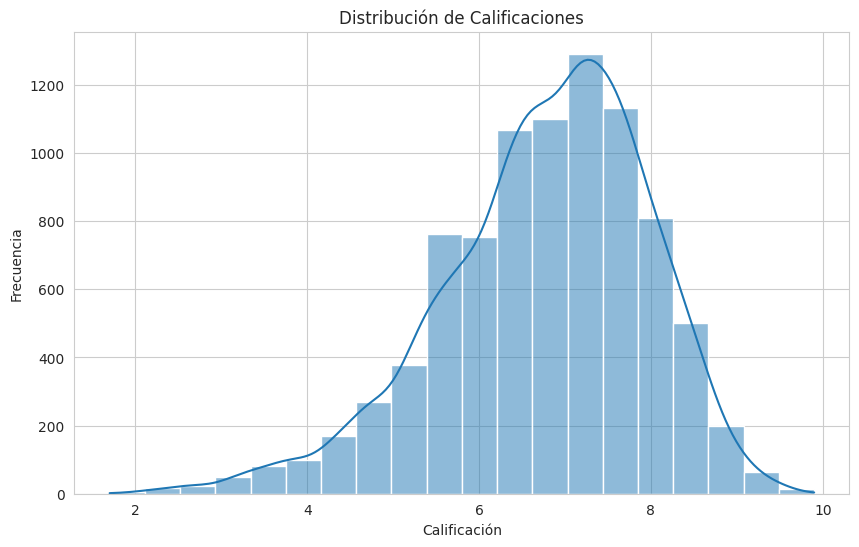

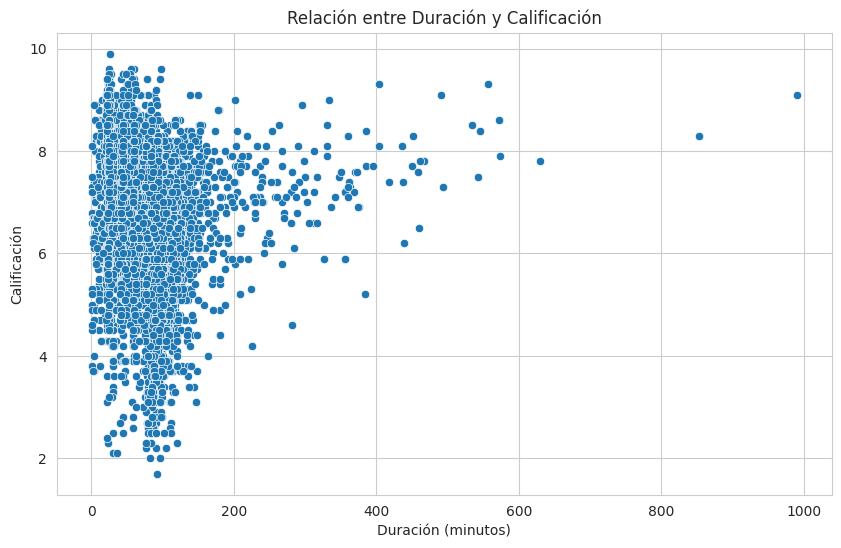

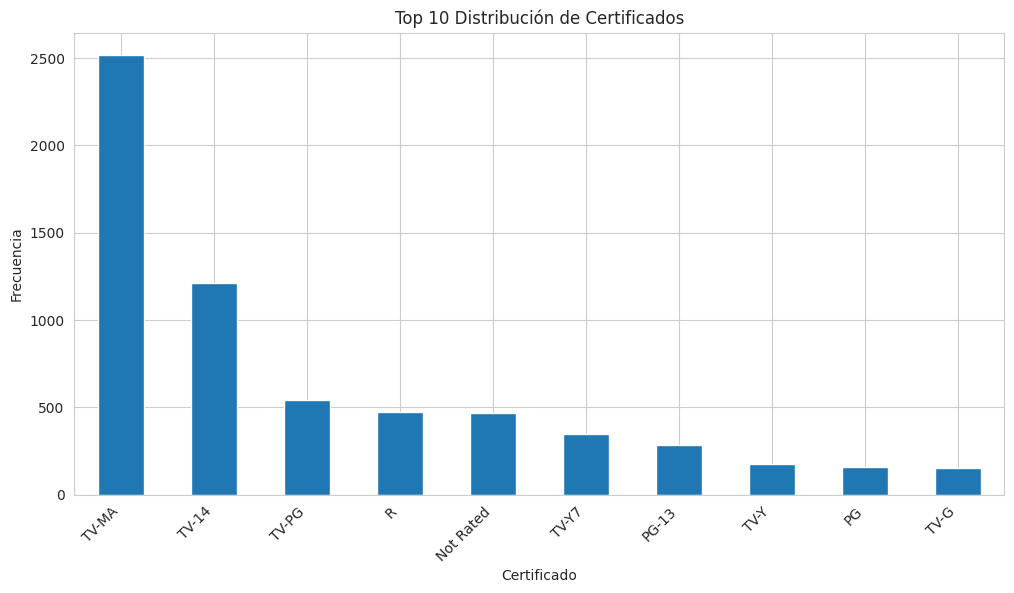

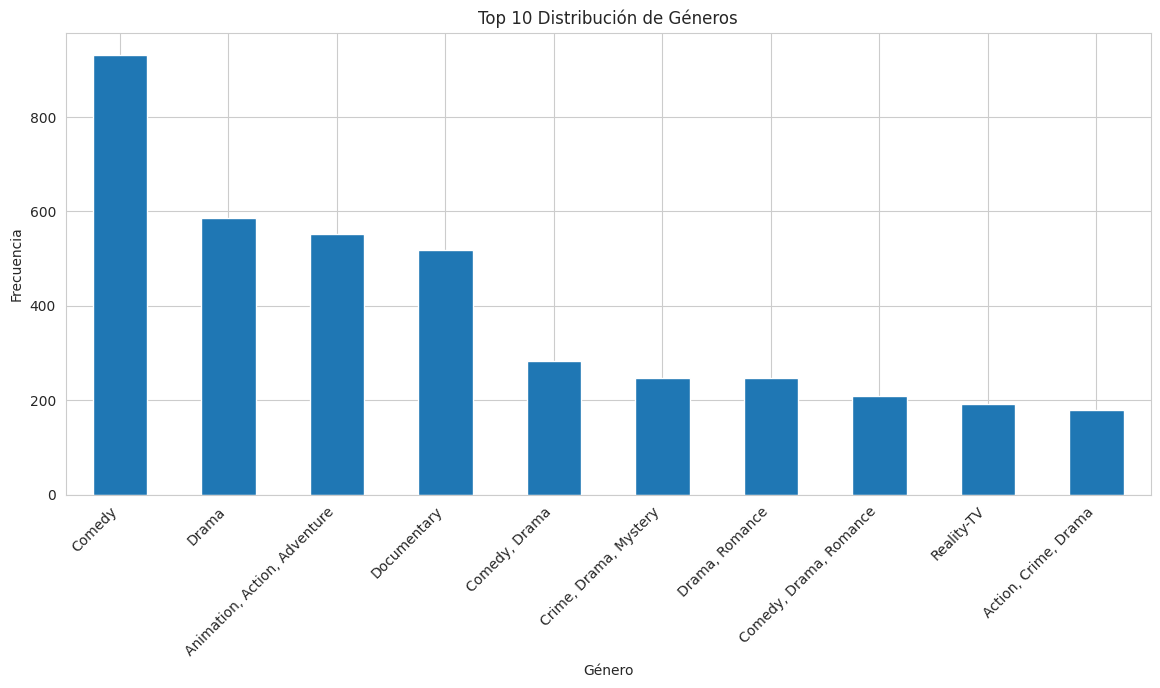

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# 2. Create a histogram of the 'rating' column
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'].dropna(), bins=20, kde=True)
plt.title('Distribución de Calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Frecuencia')
plt.show()

# 3. Create a scatter plot of 'duration' vs 'rating'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration', y='rating', data=df)
plt.title('Relación entre Duración y Calificación')
plt.xlabel('Duración (minutos)')
plt.ylabel('Calificación')
plt.show()

# 4. Create a bar plot of the top 10 certificate distributions
plt.figure(figsize=(12, 6))
certificate_distribution.head(10).plot(kind='bar')
plt.title('Top 10 Distribución de Certificados')
plt.xlabel('Certificado')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.show()

# 5. Create a bar plot of the top 10 genre distributions
plt.figure(figsize=(14, 6))
genre_distribution.head(10).plot(kind='bar')
plt.title('Top 10 Distribución de Géneros')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.show()

## Conclusión

### Subtask:
Resumir los hallazgos clave del EDA.


## Summary:

### Data Analysis Key Findings

*   The dataset contains 9957 entries with columns such as `title`, `year`, `certificate`, `duration`, `genre`, `rating`, `description`, `stars`, and `votes`.
*   Several columns initially contained missing values: `year` (527), `certificate` (3453), `duration` (2036), `genre` (73), `rating` (1173), and `votes` (1173). Missing values in `year` and `genre` were imputed using the mode.
*   The `duration` column was successfully cleaned by removing " min" and converted to a numerical format.
*   The `votes` column was cleaned by removing commas and converted to a numerical format.
*   The `stars` column was cleaned by removing brackets and single quotes.
*   The `year` column was cleaned by removing parentheses and handling ranges, then converted to an integer format, with some values becoming `NaN` due to parsing errors.
*   The distribution of `certificate` shows 'TV-MA', 'TV-14', 'TV-PG', 'R', and 'Not Rated' as some of the most frequent categories.
*   The `genre` distribution shows various combinations, indicating movies often belong to multiple genres.
*   The average title length is approximately 17.64 characters, while the average description length is around 150.24 characters.
*   Movie ratings range from 1.7 to 9.9, with an average of about 6.76. The most frequent rating is 7.2.
*   The correlation analysis for numerical columns showed relatively weak linear relationships between `year`, `duration`, `rating`, `votes`, `title_length`, and `description_length`.
*   Analyzing the mean rating by genre revealed which genres tend to have higher average ratings in the dataset.
*   Visualizations provided insights into the distribution of ratings, the relationship between duration and rating, and the frequency of top certificates and genres.

### Insights or Next Steps

*   Further investigation is needed to handle the remaining missing values in `certificate`, `duration`, `rating`, and `votes`, potentially through imputation or removal depending on the analysis goals.
*   Exploring the distribution of average ratings across different genres could reveal potential niche areas with high-quality films, warranting deeper analysis into the characteristics of movies within those genres.


# Task
Realiza una regresión lineal para predecir la columna 'rating' utilizando las columnas numéricas limpias como características. Calcula las métricas de regresión (MSE, MAE, MAPE, R2) y muestra un histograma de los errores de predicción.

## Preparación de los datos

### Subtask:
Seleccionar las características relevantes (columnas numéricas limpias) y la variable objetivo ('rating') para el modelo de regresión.


**Reasoning**:
Select the cleaned numerical columns as features (X) and the 'rating' column as the target variable (y), then drop rows with missing values in X and y to prepare the data for regression.



In [ ]:
X = df[['year', 'duration', 'votes', 'title_length', 'description_length']]
y = df['rating']

# Drop rows with missing values in X and y
data = pd.concat([X, y], axis=1).dropna()
X = data[['year', 'duration', 'votes', 'title_length', 'description_length']]
y = data['rating']

print("Dimensiones de X después de eliminar valores faltantes:", X.shape)
print("Dimensiones de y después de eliminar valores faltantes:", y.shape)

Dimensiones de X después de eliminar valores faltantes: (6674, 5)
Dimensiones de y después de eliminar valores faltantes: (6674,)


## División de los datos

### Subtask:
Dividir el conjunto de datos en conjuntos de entrenamiento y prueba.


**Reasoning**:
Import the necessary function and split the data into training and testing sets as requested by the instructions, then print the shapes of the resulting sets.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dimensiones del conjunto de entrenamiento X:", X_train.shape)
print("Dimensiones del conjunto de prueba X:", X_test.shape)
print("Dimensiones del conjunto de entrenamiento y:", y_train.shape)
print("Dimensiones del conjunto de prueba y:", y_test.shape)

Dimensiones del conjunto de entrenamiento X: (5339, 5)
Dimensiones del conjunto de prueba X: (1335, 5)
Dimensiones del conjunto de entrenamiento y: (5339,)
Dimensiones del conjunto de prueba y: (1335,)


## Entrenamiento del modelo

### Subtask:
Entrenar un modelo de regresión lineal utilizando los datos de entrenamiento.


**Reasoning**:
Import the LinearRegression class, create an instance of the model, and train it using the training data as requested by the instructions.



In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Modelo de regresión lineal entrenado.")

Modelo de regresión lineal entrenado.


## Predicción

### Subtask:
Realizar predicciones sobre el conjunto de prueba utilizando el modelo entrenado.


**Reasoning**:
Use the trained linear regression model to make predictions on the test set and store the predictions in a new variable.



In [ ]:
y_pred = model.predict(X_test)
print("Predicciones realizadas en el conjunto de prueba.")

Predicciones realizadas en el conjunto de prueba.


## Evaluación del modelo

### Subtask:
Calcular las métricas de regresión (MSE, MAE, MAPE, R2) para evaluar el rendimiento del modelo.


**Reasoning**:
Calculate MSE, MAE, R2, and MAPE to evaluate the model's performance and print these metrics.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

# Calculate MAPE, handling potential division by zero
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Handle cases where y_true is zero by adding a small epsilon
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

Mean Squared Error (MSE): 1.5790
Mean Absolute Error (MAE): 0.9705
R-squared (R2) Score: 0.0642
Mean Absolute Percentage Error (MAPE): 17.6480%


## Análisis de errores

### Subtask:
Calcular los errores de predicción y visualizar su distribución en un histograma.


**Reasoning**:
Calculate the prediction errors and create a histogram to visualize their distribution, adding a title and labels, then display the histogram.



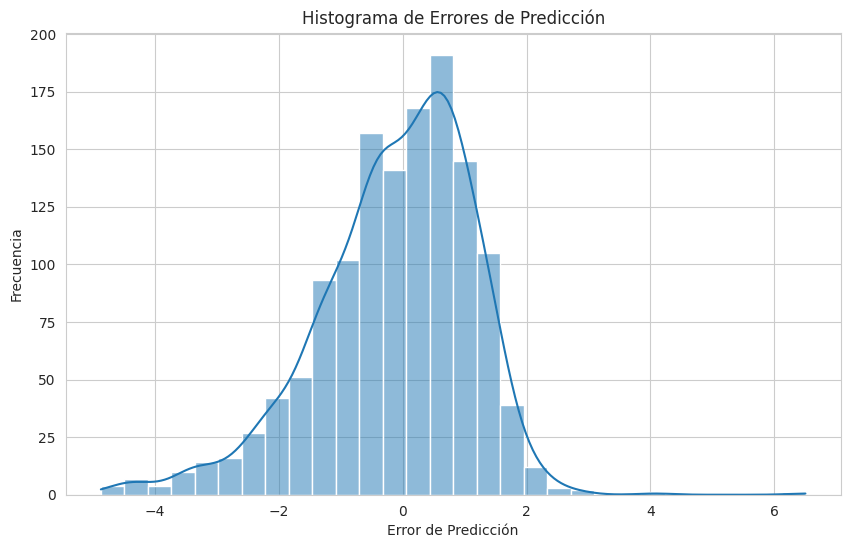

In [ ]:
prediction_errors = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(prediction_errors, bins=30, kde=True)
plt.title('Histograma de Errores de Predicción')
plt.xlabel('Error de Predicción')
plt.ylabel('Frecuencia')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The dataset was successfully prepared, selecting 'year', 'duration', 'votes', 'title\_length', and 'description\_length' as features and 'rating' as the target variable, resulting in 6674 rows with complete data.
*   The data was split into training (5339 samples) and testing (1335 samples) sets, with an 80/20 ratio.
*   A linear regression model was trained on the training data.
*   Predictions were made on the test set.
*   The model's performance on the test set was evaluated using the following metrics:
    *   Mean Squared Error (MSE): 1.5790
    *   Mean Absolute Error (MAE): 0.9705
    *   R-squared (R2) Score: 0.0642
    *   Mean Absolute Percentage Error (MAPE): 17.6480%
*   A histogram of the prediction errors was generated, showing the distribution of the differences between the actual and predicted ratings. The errors are centered around zero.

### Insights or Next Steps

*   The R2 score of 0.0642 indicates that the linear model explains only a small percentage of the variance in the 'rating', suggesting that the selected features have limited predictive power for 'rating' using a simple linear relationship.
*   Further analysis could involve exploring non-linear models, feature engineering (e.g., creating interaction terms or polynomial features), or incorporating additional relevant features to improve the prediction of 'rating'.


# Task
Realiza un análisis exploratorio de datos (EDA), una regresión lineal con métricas de regresión (MSE, MAE, MAPE, R2) e histograma de errores, y una regresión logística con métricas de clasificación (matriz de confusión y reporte de clasificación) e histograma de errores, todo en español.

## Preparación de los datos para clasificación

### Subtask:
Seleccionar las características y la variable objetivo para el modelo de regresión logística.


**Reasoning**:
Create a new categorical column 'rating_category' based on the 'rating' column, select the features and target variable for logistic regression, drop rows with missing values, and print the dimensions of the resulting dataframes.



In [ ]:
df['rating_category'] = df['rating'].apply(lambda x: 'alta calificación' if x >= 7.0 else 'baja calificación')

X_log = df[['year', 'duration', 'votes', 'title_length', 'description_length']]
y_log = df['rating_category']

data_log = pd.concat([X_log, y_log], axis=1).dropna()
X_log = data_log[['year', 'duration', 'votes', 'title_length', 'description_length']]
y_log = data_log['rating_category']

print("Dimensiones de X_log después de eliminar valores faltantes:", X_log.shape)
print("Dimensiones de y_log después de eliminar valores faltantes:", y_log.shape)

Dimensiones de X_log después de eliminar valores faltantes: (6674, 5)
Dimensiones de y_log después de eliminar valores faltantes: (6674,)


## División de los datos

### Subtask:
Dividir el conjunto de datos en conjuntos de entrenamiento y prueba para el modelo de regresión logística.


**Reasoning**:
Import the necessary function and split the data into training and testing sets as requested by the instructions, then print the shapes of the resulting sets.



In [ ]:
from sklearn.model_selection import train_test_split

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

print("Dimensiones del conjunto de entrenamiento X para clasificación:", X_train_log.shape)
print("Dimensiones del conjunto de prueba X para clasificación:", X_test_log.shape)
print("Dimensiones del conjunto de entrenamiento y para clasificación:", y_train_log.shape)
print("Dimensiones del conjunto de prueba y para clasificación:", y_test_log.shape)

Dimensiones del conjunto de entrenamiento X para clasificación: (5339, 5)
Dimensiones del conjunto de prueba X para clasificación: (1335, 5)
Dimensiones del conjunto de entrenamiento y para clasificación: (5339,)
Dimensiones del conjunto de prueba y para clasificación: (1335,)


## Entrenamiento del modelo de regresión logística

### Subtask:
Entrenar un modelo de regresión logística utilizando los datos de entrenamiento.


**Reasoning**:
Import the LogisticRegression class, create an instance of the model, and train it using the training data as requested by the instructions.



In [ ]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train_log, y_train_log)

print("Modelo de regresión logística entrenado.")

Modelo de regresión logística entrenado.


## Predicción

### Subtask:
Realizar predicciones sobre el conjunto de prueba utilizando el modelo de regresión logística entrenado.


**Reasoning**:
Use the trained logistic regression model to make predictions on the test set and store the predictions in a new variable, then print a message confirming that the predictions have been made.



In [ ]:
y_pred_log = model_log.predict(X_test_log)
print("Predicciones realizadas en el conjunto de prueba para clasificación.")

Predicciones realizadas en el conjunto de prueba para clasificación.


## Evaluación del modelo de clasificación

### Subtask:
Calcular y mostrar la matriz de confusión y el reporte de clasificación para evaluar el rendimiento del modelo de regresión logística.


**Reasoning**:
Calculate and display the confusion matrix and classification report for the logistic regression model to evaluate its performance.



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test_log, y_pred_log)
print("Matriz de Confusión:")
display(conf_matrix)

# Generate and print the classification report
class_report = classification_report(y_test_log, y_pred_log)
print("\nReporte de Clasificación:")
print(class_report)

Matriz de Confusión:


array([[444, 200],
       [233, 458]])


Reporte de Clasificación:
                   precision    recall  f1-score   support

alta calificación       0.66      0.69      0.67       644
baja calificación       0.70      0.66      0.68       691

         accuracy                           0.68      1335
        macro avg       0.68      0.68      0.68      1335
     weighted avg       0.68      0.68      0.68      1335



## Análisis de errores de clasificación

### Subtask:
Calcular los errores de predicción y visualizar su distribución en un histograma.


**Reasoning**:
Calculate the prediction errors (incorrect predictions) and visualize their distribution using a histogram, with appropriate titles and labels.



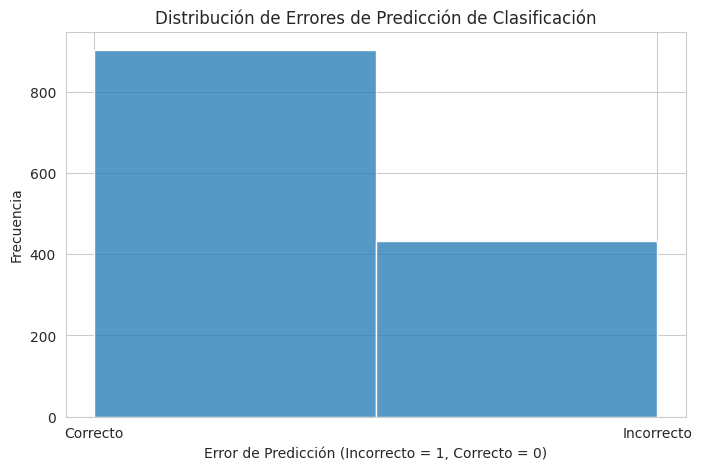

In [ ]:
prediction_errors_log = (y_test_log != y_pred_log)

plt.figure(figsize=(8, 5))
sns.histplot(prediction_errors_log.astype(int), bins=2, kde=False)
plt.title('Distribución de Errores de Predicción de Clasificación')
plt.xlabel('Error de Predicción (Incorrecto = 1, Correcto = 0)')
plt.ylabel('Frecuencia')
plt.xticks([0, 1], ['Correcto', 'Incorrecto'])
plt.show()

## Summary:

### Data Analysis Key Findings

*   After handling missing values, the dataset for logistic regression contains 6674 samples with 5 features.
*   The dataset was split into training (5339 samples) and testing (1335 samples) sets for the logistic regression model.
*   The logistic regression model was successfully trained.
*   The confusion matrix and classification report were generated, providing metrics like precision, recall, F1-score, and support for "alta calificación" and "baja calificación" classes, as well as overall accuracy.
*   A histogram was generated showing the distribution of correct (0) and incorrect (1) predictions made by the logistic regression model on the test set.

### Insights or Next Steps

*   Analyze the classification report and confusion matrix to understand the model's performance for each class and identify potential areas for improvement (e.g., imbalanced classes, specific types of misclassifications).
*   Based on the error distribution histogram, evaluate if the number of incorrect predictions is acceptable and consider exploring techniques to reduce errors if necessary.
